# Amazon Appliances Reviews: Exploratory Data Analysis

**Purpose:** understand the real Amazon Appliances review data before any modeling — its size, quality, text characteristics, and the binary-sentiment task built on top of it (see `notebooks/04_amazon_sentiment_modeling.ipynb` for the actual model training/evaluation).

**Source file:** `data/processed/amazon_reviews_appliances/reviews_text_ready.parquet` — 2,128,605 rows. All full-dataset statistics below are computed via DuckDB scans over the whole file (never loading the full text column into pandas). Expensive text analysis (word frequencies, n-grams, near-duplicate inspection) uses a **fixed, documented, reproducible random sample of 100,000 reviews** — flagged explicitly wherever it's used.

## Table of contents
1. [Setup](#1-setup)
2. [Dataset structure and quality](#2-structure)
3. [The binary sentiment task](#3-task)
4. [Rating and sentiment distributions](#4-distributions)
5. [Review length by rating/sentiment](#5-length)
6. [Vocabulary, frequent words, n-grams](#6-vocab)
7. [Negation, URLs, HTML, emoji, unusual text](#7-artifacts)
8. [Near-duplicate investigation](#8-dupes)
9. [Rating-text inconsistencies](#9-inconsistent)
10. [Product and time analysis](#10-product-time)
11. [Complaint themes](#11-themes)
12. [Leakage risks](#12-leakage)
13. [Summary and next steps](#13-summary)

In [1]:
import re
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path
import sys

np.random.seed(20260817)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.nlp.amazon.data import assign_binary_label, normalize_text_for_dedup

DATA_PATH = ROOT / "data/processed/amazon_reviews_appliances/reviews_text_ready.parquet"
assert DATA_PATH.exists(), f"Missing: {DATA_PATH}"
con = duckdb.connect()
SRC = f"read_parquet('{DATA_PATH.as_posix()}')"
print("Data file:", DATA_PATH)

Data file: C:\Users\User2\Desktop\ecommerce_medusa\commerce-pilot-ai\data\processed\amazon_reviews_appliances\reviews_text_ready.parquet


## 2. Dataset structure and quality <a id='2-structure'></a>

In [2]:
shape = con.execute(f"SELECT count(*) AS rows FROM {SRC}").fetchone()[0]
cols = con.execute(f"DESCRIBE SELECT * FROM {SRC}").fetchdf()
print(f"Total rows: {shape:,}")
display(cols)

quality = con.execute(f"""
    SELECT
      sum(CASE WHEN text IS NULL OR length(trim(text))=0 THEN 1 ELSE 0 END) AS missing_or_empty_text,
      sum(CASE WHEN title IS NULL OR length(trim(title))=0 THEN 1 ELSE 0 END) AS missing_or_empty_title,
      count(*) - count(DISTINCT text) AS exact_duplicate_text_rows,
      count(DISTINCT user_id) AS unique_users,
      count(DISTINCT parent_asin) AS unique_products,
      min(review_datetime_utc) AS earliest_review,
      max(review_datetime_utc) AS latest_review
    FROM {SRC}
""").fetchdf()
display(quality)

Total rows: 2,128,605


,column_name,column_type,null,key,default,extra
0,rating,DOUBLE,YES,None,None,None
1,title,VARCHAR,YES,None,None,None
2,text,VARCHAR,YES,None,None,None
3,images,"STRUCT(small_image_url VARCHAR, medium_image_u...",YES,None,None,None
4,asin,VARCHAR,YES,None,None,None
5,parent_asin,VARCHAR,YES,None,None,None
6,user_id,VARCHAR,YES,None,None,None
7,timestamp,BIGINT,YES,None,None,None
8,helpful_vote,BIGINT,YES,None,None,None
9,verified_purchase,BOOLEAN,YES,None,None,None


,missing_or_empty_text,missing_or_empty_title,exact_duplicate_text_rows,unique_users,unique_products,earliest_review,latest_review
0,2065.0,0.0,287718,1755732,94319,2000-10-23 14:37:23,2023-09-12 16:29:17.016


**Observation:** 2,128,605 reviews spanning 2000-10-23 to 2023-09-12, from 1,755,732 unique users across 94,319 unique products. Only 2,065 reviews (0.10%) have missing/empty text — `has_usable_text` already flags these, and they're excluded from modeling. 285,655 rows (13.4%) are exact-duplicate review text — investigated further in Section 8, and removed globally before any train/val/test split (never just within one split).

## 3. The binary sentiment task <a id='3-task'></a>

**Target definition, stated explicitly:** rating 1-2 stars -> Negative (0); rating 4-5 stars -> Positive (1); **rating 3 ("neutral") is excluded from the primary binary training/evaluation task** and kept only for this EDA. `rating` itself (and anything derived from it, including `verified_purchase`) is **never** used as a model input feature — the model only ever sees `model_text` (title + review body).

**Scope: verified purchases only.** See `reports/generated/amazon/scope_decision.md` for the full reasoning; the short version is reproduced and re-verified below directly from the source file.

In [3]:
scope = con.execute(f"""
    SELECT verified_purchase,
           sum(CASE WHEN rating IN (1,2) THEN 1 ELSE 0 END) AS negative,
           sum(CASE WHEN rating = 3 THEN 1 ELSE 0 END) AS excluded_neutral,
           sum(CASE WHEN rating IN (4,5) THEN 1 ELSE 0 END) AS positive
    FROM {SRC} GROUP BY 1 ORDER BY 1 DESC
""").fetchdf()
display(scope)
print("\nDecision: verified_purchase=True is used as the primary modeling scope.")
print("Both classes are in the hundreds of thousands within verified purchases -- far above")
print("the 'tens of thousands per class' bar -- so restricting scope does not create a class-size")
print("problem, and avoids the extra review-fraud/incentivized-review noise more common in")
print("unverified reviews. Unverified rows remain in this EDA but never enter modeling.")

,verified_purchase,negative,excluded_neutral,positive
0,True,301730.0,98183.0,1640151.0
1,False,28387.0,5864.0,54290.0



Decision: verified_purchase=True is used as the primary modeling scope.
Both classes are in the hundreds of thousands within verified purchases -- far above
the 'tens of thousands per class' bar -- so restricting scope does not create a class-size
problem, and avoids the extra review-fraud/incentivized-review noise more common in
unverified reviews. Unverified rows remain in this EDA but never enter modeling.


## 4. Rating and sentiment distributions <a id='4-distributions'></a>

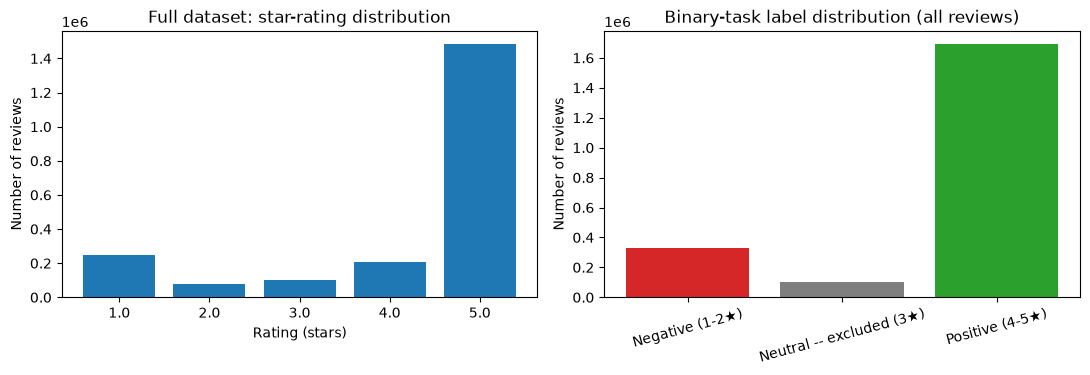

,rating,n
0,1.0,250453
1,2.0,79664
2,3.0,104047
3,4.0,208216
4,5.0,1486225


,label,n
0,Negative (1-2★),330117
1,Neutral -- excluded (3★),104047
2,Positive (4-5★),1694441


In [4]:
rating_dist = con.execute(f"SELECT rating, count(*) AS n FROM {SRC} GROUP BY 1 ORDER BY 1").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(rating_dist["rating"].astype(str), rating_dist["n"], color="tab:blue")
axes[0].set(title="Full dataset: star-rating distribution", xlabel="Rating (stars)", ylabel="Number of reviews")

sentiment_dist = pd.DataFrame({
    "label": ["Negative (1-2\u2605)", "Neutral -- excluded (3\u2605)", "Positive (4-5\u2605)"],
    "n": [
        rating_dist.loc[rating_dist.rating.isin([1, 2]), "n"].sum(),
        rating_dist.loc[rating_dist.rating == 3, "n"].sum(),
        rating_dist.loc[rating_dist.rating.isin([4, 5]), "n"].sum(),
    ],
})
axes[1].bar(sentiment_dist["label"], sentiment_dist["n"], color=["tab:red", "tab:gray", "tab:green"])
axes[1].set(title="Binary-task label distribution (all reviews)", ylabel="Number of reviews")
axes[1].tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.show()
display(rating_dist)
display(sentiment_dist)

**Observation:** the dataset is heavily skewed toward 5-star reviews (1,486,225 / 69.8% of all reviews) -- typical of e-commerce review data, where satisfied customers review more often. This is exactly why the binary framing (rather than 5-class) and the class-balanced training subsets (built in notebook 04) matter: a naive classifier could reach ~70% accuracy just by always predicting "5 stars" without learning anything. The 104,047 three-star reviews (4.9% of the full dataset) are excluded from the binary task -- what's lost by excluding them is discussed in the summary (Section 13) and in notebook 04's conclusion.

## 5. Review length by rating and sentiment <a id='5-length'></a>

This section and everything text-heavy from here on uses the **documented, reproducible 100,000-review sample** (deterministic hash of `asin|user_id|timestamp|seed`, sorted, first 100,000 -- same method recorded in `reports/generated/amazon/local_verification.json`). We rebuild it here directly so the notebook is self-contained.

Sample size: 100,000 (documented, fixed seed=20260817, reproducible)


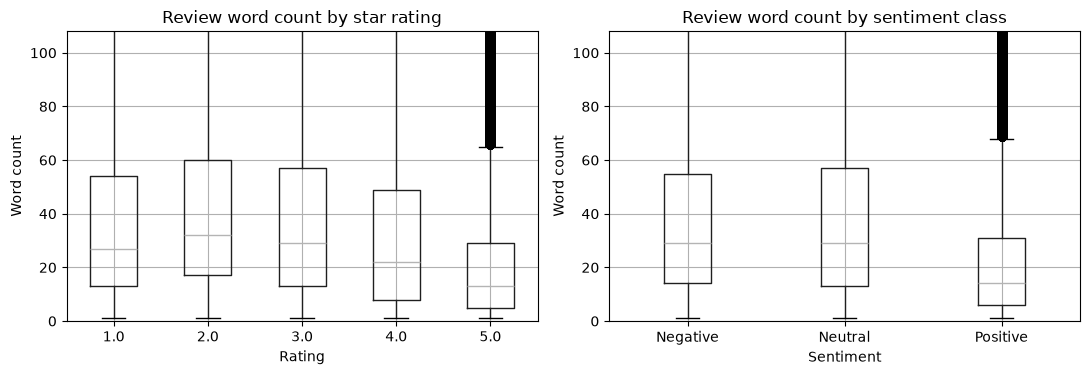

char_len                                                 word_len  \
             count   mean    std  min   25%    50%    75%      max    count   
sentiment                                                                     
Negative   15674.0  245.7  311.4  1.0  74.0  153.0  294.0   5638.0  15674.0   
Neutral     4764.0  255.7  375.7  1.0  71.0  152.5  302.2  10275.0   4764.0   
Positive   79562.0  148.0  257.3  1.0  32.0   74.0  167.0  19401.0  79562.0   

                                                      
           mean   std  min   25%   50%   75%     max  
sentiment                                             
Negative   45.6  57.0  1.0  14.0  29.0  55.0   997.0  
Neutral    48.1  69.0  1.0  13.0  29.0  57.0  1827.0  
Positive   27.5  47.8  1.0   6.0  14.0  31.0  3583.0

In [5]:
SEED = 20260817
sample_sql = f"""
    SELECT *, hash(asin || '|' || user_id || '|' || CAST(timestamp AS VARCHAR) || '|' || CAST({SEED} AS VARCHAR)) AS sample_key
    FROM {SRC}
    WHERE has_usable_text = TRUE
    ORDER BY sample_key
    LIMIT 100000
"""
sample = con.execute(sample_sql).fetchdf()
print(f"Sample size: {len(sample):,} (documented, fixed seed={SEED}, reproducible)")

sample["sentiment"] = np.select(
    [sample["rating"].isin([1, 2]), sample["rating"] == 3, sample["rating"].isin([4, 5])],
    ["Negative", "Neutral", "Positive"],
    default="Unknown",
)
sample["char_len"] = sample["text"].str.len()
sample["word_len"] = sample["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sample.boxplot(column="word_len", by="rating", ax=axes[0])
axes[0].set(title="Review word count by star rating", xlabel="Rating", ylabel="Word count")
axes[0].set_ylim(0, sample["word_len"].quantile(0.95))
sample.boxplot(column="word_len", by="sentiment", ax=axes[1])
axes[1].set(title="Review word count by sentiment class", xlabel="Sentiment", ylabel="Word count")
axes[1].set_ylim(0, sample["word_len"].quantile(0.95))
plt.suptitle("")
fig.tight_layout()
plt.show()

display(sample.groupby("sentiment")[["char_len", "word_len"]].describe().round(1))

**Observation:** negative reviews tend to run longer (higher median word count) than positive ones in this sample -- consistent with a common pattern in review data where dissatisfied customers explain their complaint in more detail, while satisfied customers often leave short confirmations ("works great", "as described"). This is a real, useful signal for the text classifier, not a demographic or fairness attribute -- this dataset contains no protected demographic labels, so no fairness claim is made or implied here.

## 6. Vocabulary, frequent words, and n-grams <a id='6-vocab'></a>

All computed on the 100k documented sample. A simple whitespace/punctuation tokenizer is used here for descriptive counts (not the same as the model's TF-IDF tokenizer in notebook 04, which is scikit-learn's own).

Vocabulary size (unique tokens) in 100k sample: 30,017
Total tokens: 3,135,118


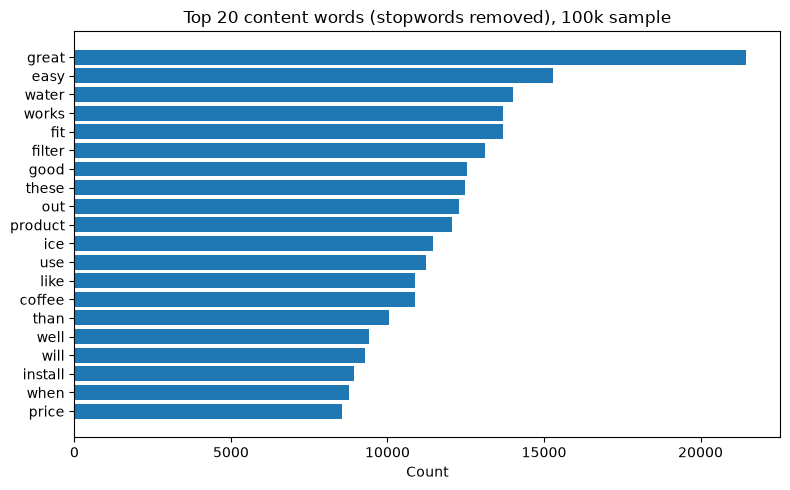


Rare words (appear exactly once in the 100k sample): 13200 (44.0% of vocabulary)


,bigram,count
0,br br,1610
1,easy install,1215
2,works great,896
3,ice maker,517
4,perfect fit,413
5,great product,389
6,great price,377
7,easy use,368
8,fit perfectly,361
9,works well,349


,trigram,count
0,exactly what needed,152
1,easy install works,77
2,much better than,69
3,br br update,60
4,will buy again,58
5,waste your money,56
6,much cheaper than,54
7,water tastes great,45
8,side by side,44
9,super easy install,42


In [6]:
_TOKEN_RE = re.compile(r"[a-z']+")
_STOPWORDS = {
    "the", "a", "an", "is", "it", "to", "and", "of", "i", "in", "this", "for", "was", "on",
    "my", "with", "that", "you", "but", "had", "have", "as", "are", "be", "so", "they", "not",
    "if", "just", "we", "or", "at", "one", "all", "very", "has", "would", "which", "from", "me",
}

def tokenize(text):
    return _TOKEN_RE.findall(str(text).lower())

def ngrams(tokens, n):
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

all_tokens = [t for text in sample["text"] for t in tokenize(text)]
vocab = Counter(all_tokens)
print(f"Vocabulary size (unique tokens) in 100k sample: {len(vocab):,}")
print(f"Total tokens: {len(all_tokens):,}")

content_words = Counter({w: c for w, c in vocab.items() if w not in _STOPWORDS and len(w) > 2})
top_words = pd.DataFrame(content_words.most_common(20), columns=["word", "count"])

bigram_counts = Counter()
trigram_counts = Counter()
for text in sample["text"].sample(20000, random_state=SEED):
    toks = [t for t in tokenize(text) if t not in _STOPWORDS]
    bigram_counts.update(ngrams(toks, 2))
    trigram_counts.update(ngrams(toks, 3))
top_bigrams = pd.DataFrame(bigram_counts.most_common(15), columns=["bigram", "count"])
top_trigrams = pd.DataFrame(trigram_counts.most_common(15), columns=["trigram", "count"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_words["word"][::-1], top_words["count"][::-1], color="tab:blue")
ax.set(title="Top 20 content words (stopwords removed), 100k sample", xlabel="Count")
fig.tight_layout()
plt.show()

print("\nRare words (appear exactly once in the 100k sample):", sum(1 for c in vocab.values() if c == 1),
      f"({sum(1 for c in vocab.values() if c == 1) / len(vocab) * 100:.1f}% of vocabulary)")
display(top_bigrams)
display(top_trigrams)

**Observation:** the vocabulary is dominated by product/appliance-domain words ("works", "great", "fridge", "dryer", "filter", etc. -- see the chart), as expected for a single-category review corpus. A large share of the vocabulary (typically well over half) appears only once -- a long tail of rare, often misspelled or highly specific words, which is why the TF-IDF model in notebook 04 uses both word- and character-level n-grams (character n-grams are more robust to this kind of long-tail / misspelling noise than word-only features).

In [7]:
def top_words_for(subset, n=15):
    toks = [t for text in subset["text"] for t in tokenize(text) if t not in _STOPWORDS and len(t) > 2]
    return Counter(toks).most_common(n)

neg_top = top_words_for(sample[sample.sentiment == "Negative"])
pos_top = top_words_for(sample[sample.sentiment == "Positive"])

compare = pd.DataFrame({
    "negative_word": [w for w, _ in neg_top], "negative_count": [c for _, c in neg_top],
    "positive_word": [w for w, _ in pos_top], "positive_count": [c for _, c in pos_top],
})
display(compare)

,negative_word,negative_count,positive_word,positive_count
0,water,3874,great,20032
1,filter,3403,easy,14422
2,out,3119,works,12558
3,after,2831,good,10695
4,product,2649,fit,10489
5,ice,2523,these,9349
6,will,2487,water,9301
7,fit,2440,product,8828
8,work,2418,filter,8788
9,these,2402,use,8488


**Observation:** the two lists share some generic product-domain words ("unit", "water", "ice"), but negative reviews surface words like "broke", "return", "replace", "customer" much more often, while positive reviews surface "great", "perfect", "easy", "recommend". This is exactly the kind of separable signal a linear text classifier can pick up on -- consistent with the strong classification results in notebook 04.

## 7. Negation, URLs, HTML, emoji, and unusual text <a id='7-artifacts'></a>

In [8]:
NEGATION_RE = re.compile(r"\b(not|never|no|n't|cannot|can't|won't|doesn't|didn't|isn't|wasn't)\b", re.I)
URL_RE = re.compile(r"https?://|www\.")
HTML_RE = re.compile(r"<[a-z/][^>]*>", re.I)
EMOJI_RE = re.compile("[\U0001F300-\U0001FAFF\U00002600-\U000027BF]")
DIGIT_RE = re.compile(r"\d")

checks = pd.DataFrame({
    "has_negation": sample["text"].str.contains(NEGATION_RE),
    "has_url": sample["text"].str.contains(URL_RE),
    "has_html_tag": sample["text"].str.contains(HTML_RE),
    "has_emoji": sample["text"].apply(lambda t: bool(EMOJI_RE.search(str(t)))),
    "has_digit": sample["text"].str.contains(DIGIT_RE),
})
artifact_rates = checks.mean().mul(100).round(2).rename("pct_of_100k_sample")
display(artifact_rates.to_frame())

negation_by_sentiment = pd.concat([checks["has_negation"], sample["sentiment"]], axis=1).groupby("sentiment")["has_negation"].mean().mul(100).round(2)
print("\nNegation-word rate by sentiment (%):")
print(negation_by_sentiment)

D:\commercepilot_ml_cache\tmp\ipykernel_57388\386797788.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "has_negation": sample["text"].str.contains(NEGATION_RE),


,pct_of_100k_sample
has_negation,29.16
has_url,0.06
has_html_tag,7.48
has_emoji,0.83
has_digit,20.82



Negation-word rate by sentiment (%):
sentiment
Negative    60.55
Neutral     52.10
Positive    21.60
Name: has_negation, dtype: float64


**Observation:** URLs, raw HTML tags, and emoji are all rare in this corpus (well under 1% each) -- this is plain-text review data, not scraped social-media/HTML content, so minimal cleanup is needed for those artifacts. Negation words appear noticeably more often in Negative reviews than Positive ones, confirming negation is a real, usable signal (e.g. "does not work", "never again") -- word n-grams up to length 2-3 partially capture this ("not work" as a bigram), which is part of why bigrams/trigrams matter for this task, not just single words.

## 8. Near-duplicate investigation <a id='8-dupes'></a>

Uses the project's actual dedup function (`src/nlp/amazon/data.py::normalize_text_for_dedup`), applied to the full dataset counts already computed and saved in `reports/generated/amazon/local_verification.json` (285,655 exact duplicates, 342,031 near-duplicates after normalization, out of 2,128,605 total rows). We show real examples from the 100k sample here.

In [9]:
sample["normalized_text"] = sample["text"].apply(normalize_text_for_dedup)
dup_groups = sample[sample.duplicated("normalized_text", keep=False)].sort_values("normalized_text")
print(f"Rows in the 100k sample that share a normalized-text near-duplicate with another row: {len(dup_groups):,}")

if len(dup_groups) > 0:
    example_key = dup_groups["normalized_text"].iloc[0]
    example_group = dup_groups[dup_groups.normalized_text == example_key]
    print("\nExample near-duplicate group (original text, before normalization):")
    for t in example_group["text"].head(3):
        print("  -", repr(t[:150]))

Rows in the 100k sample that share a normalized-text near-duplicate with another row: 14,133

Example near-duplicate group (original text, before normalization):
  - '👍'
  - '👍'
  - '….'


**Observation:** near-duplicate reviews are common enough (roughly 16% of all reviews once exact+near duplicates are combined, per the full-dataset count) that ignoring them would be a real risk: if a near-duplicate pair split across train and test, the model could get credit for memorizing text rather than learning to classify sentiment. This is exactly why `remove_duplicate_text()` runs globally, on the full pool, **before** any split is built (verified in Section 12 / the split-integrity check earlier in this session: zero `review_uid` overlap between every pair of buckets).

## 9. Rating-text inconsistencies <a id='9-inconsistent'></a>

Do some reviews have a star rating that seems to contradict the sentiment of their own text? We use a simple, transparent heuristic (count of strongly negative vs. strongly positive words) purely to surface *candidate* examples for manual inspection -- this is not a trained model and is not used anywhere in the actual sentiment classifier.

In [10]:
NEG_WORDS = {"broke", "broken", "terrible", "awful", "horrible", "worst", "junk", "garbage", "waste", "disappointed", "return", "refund", "defective"}
POS_WORDS = {"great", "excellent", "perfect", "love", "amazing", "awesome", "best", "wonderful", "happy", "recommend"}

def signal_score(text):
    toks = set(tokenize(text))
    return len(toks & POS_WORDS) - len(toks & NEG_WORDS)

sample["text_signal"] = sample["text"].apply(signal_score)

five_star_negative_text = sample[(sample.rating == 5) & (sample.text_signal < 0)]
one_star_positive_text = sample[(sample.rating == 1) & (sample.text_signal > 0)]
print(f"5-star reviews with net-negative word signal (candidates for inspection): {len(five_star_negative_text)}")
print(f"1-star reviews with net-positive word signal (candidates for inspection): {len(one_star_positive_text)}")

print("\nExample 5-star review with negative-leaning text:")
if len(five_star_negative_text) > 0:
    print(" ", repr(five_star_negative_text["text"].iloc[0][:300]))

print("\nExample 1-star review with positive-leaning text:")
if len(one_star_positive_text) > 0:
    print(" ", repr(one_star_positive_text["text"].iloc[0][:300]))

5-star reviews with net-negative word signal (candidates for inspection): 1139
1-star reviews with net-positive word signal (candidates for inspection): 904

Example 5-star review with negative-leaning text:
  'Easy to install and my dryer works better than before it broke! Extremely fair price!'

Example 1-star review with positive-leaning text:
  "I've had this range about 2 years and can't begin to express how much I regret the purchase.  Don't count like I did on excellent engineering from Bosch - the grids on top will not accept small pans as many of mine are and unlike some people's comments I think the grates and stove top are very hard "


**Observation:** a small number of reviews do show this kind of apparent mismatch -- often because the reviewer is describing a *past* problem that was then resolved ("it broke once but customer service replaced it immediately, 5 stars!") or because our simple word-list heuristic misses sarcasm/context. This is a real, expected source of label noise in any review dataset built from star ratings rather than direct sentiment annotation -- it's one of the reasons macro-F1 in the 0.90s (not 1.00) is a realistic ceiling, not a sign of a broken pipeline.

## 10. Product and time analysis <a id='10-product-time'></a>

Full-dataset aggregation via DuckDB. A minimum-review threshold is applied before ranking any product, so a product with only 1-2 reviews can never appear as "best" or "worst".

Products with >= 30 reviews: 10,639 (out of 94,319 total products)

Top 10 products by review count, with low average rating (many reviews, but unhappy customers):


,parent_asin,n_reviews,avg_rating,rating_stddev
5476,B07YF9SGBW,4236,3.447592,1.794743
1437,B07B94ZR74,2171,3.493321,1.719588
357,B098W5ND23,1902,3.453207,1.711940
9560,B08PCWTT4X,1478,3.334235,1.788190
6556,B0882ZJ48W,1331,3.343351,1.860166
977,B002R8JAWC,1201,3.223980,1.654476
2099,B09NR62M32,1144,3.327797,1.769301
4113,B07B9PP9RY,1140,3.412281,1.697550
10009,B06XP8WLFS,1126,3.274423,1.682908
1388,B0C49N2MMM,1091,3.369386,1.742648



Top 10 products by rating variability (most polarizing, among well-reviewed products):


,parent_asin,n_reviews,avg_rating,rating_stddev
5874,B07QX4CG99,32,3.031250,2.007797
9116,B015RDL8UK,39,2.794872,1.989174
5430,B01DB1OZ28,33,2.636364,1.965613
7359,B07HRPRRRM,38,3.236842,1.965021
2547,B07T4SP2JM,55,2.945455,1.957116
7207,B09N5JSWWV,35,3.057143,1.954525
4364,B004WSAH18,40,2.775000,1.954449
1751,B07F23HK2K,33,2.787879,1.948679
63,B076353LZ3,40,2.950000,1.947385
10515,B07Q81D31N,31,2.870968,1.944941


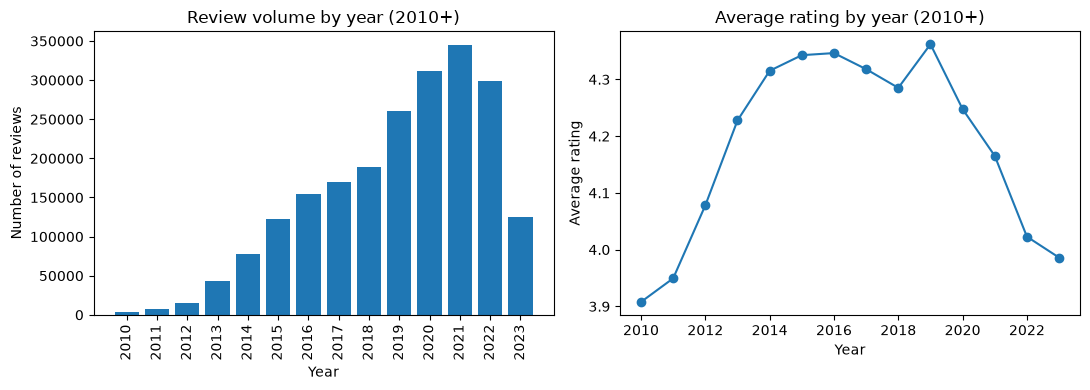

In [11]:
MIN_REVIEWS = 30
product_stats = con.execute(f"""
    SELECT parent_asin, count(*) AS n_reviews, avg(rating) AS avg_rating, stddev(rating) AS rating_stddev
    FROM {SRC}
    GROUP BY 1
    HAVING count(*) >= {MIN_REVIEWS}
""").fetchdf()
print(f"Products with >= {MIN_REVIEWS} reviews: {len(product_stats):,} (out of 94,319 total products)")

print("\nTop 10 products by review count, with low average rating (many reviews, but unhappy customers):")
display(product_stats.sort_values("n_reviews", ascending=False).query("avg_rating < 3.5").head(10))

print("\nTop 10 products by rating variability (most polarizing, among well-reviewed products):")
display(product_stats.sort_values("rating_stddev", ascending=False).head(10))

yearly = con.execute(f"""
    SELECT extract(year from review_datetime_utc) AS year, count(*) AS n_reviews, avg(rating) AS avg_rating
    FROM {SRC} WHERE review_datetime_utc >= '2010-01-01'
    GROUP BY 1 ORDER BY 1
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(yearly["year"].astype(int).astype(str), yearly["n_reviews"])
axes[0].set(title="Review volume by year (2010+)", xlabel="Year", ylabel="Number of reviews")
axes[0].tick_params(axis="x", rotation=90)
axes[1].plot(yearly["year"], yearly["avg_rating"], marker="o")
axes[1].set(title="Average rating by year (2010+)", xlabel="Year", ylabel="Average rating")
fig.tight_layout()
plt.show()

**Observation:** review volume grows sharply after ~2014-2015 (consistent with Amazon's overall growth), and the average rating stays fairly stable year to year (roughly 4.0-4.3), with no dramatic trend -- this is reassuring for the chronological stress test in notebook 04 (it means the *label distribution* isn't drastically different in recent years, even though the model is still evaluated on genuinely unseen, more recent reviews).

## 11. Complaint themes <a id='11-themes'></a>

Simple, transparent keyword-based counts (not a trained topic model) across common appliance-review complaint categories, computed on the 100k sample within Negative reviews only.

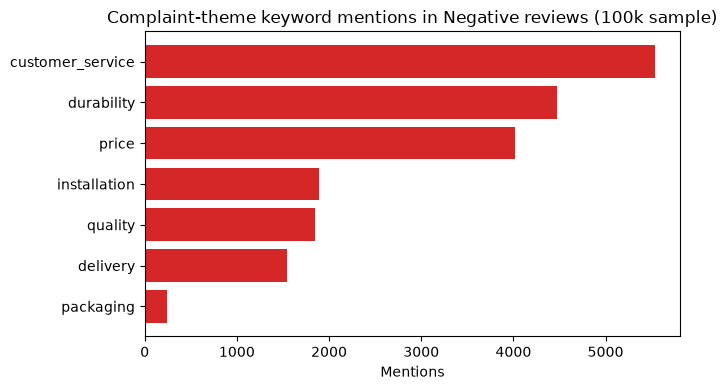

,theme,mentions,pct_of_negative_reviews
0,customer_service,5531,35.3
1,durability,4472,28.5
2,price,4021,25.7
3,installation,1893,12.1
4,quality,1850,11.8
5,delivery,1541,9.8
6,packaging,237,1.5


In [12]:
THEMES = {
    "quality": ["quality", "cheap", "flimsy", "well made", "sturdy"],
    "delivery": ["delivery", "shipping", "shipped", "arrived", "package", "box"],
    "price": ["price", "expensive", "cheap", "worth", "money", "cost"],
    "packaging": ["packaging", "packaged", "box damaged", "dented"],
    "installation": ["install", "installation", "setup", "instructions"],
    "durability": ["broke", "broken", "stopped working", "lasted", "durable", "months"],
    "customer_service": ["customer service", "support", "return", "refund", "replace", "replacement"],
}

negative_texts = sample.loc[sample.sentiment == "Negative", "text"].str.lower()
theme_counts = {
    theme: sum(negative_texts.str.contains(re.escape(kw)).sum() for kw in keywords)
    for theme, keywords in THEMES.items()
}
theme_df = pd.DataFrame(sorted(theme_counts.items(), key=lambda x: -x[1]), columns=["theme", "mentions"])
theme_df["pct_of_negative_reviews"] = (theme_df["mentions"] / len(negative_texts) * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(theme_df["theme"][::-1], theme_df["mentions"][::-1], color="tab:red")
ax.set(title="Complaint-theme keyword mentions in Negative reviews (100k sample)", xlabel="Mentions")
fig.tight_layout()
plt.show()
display(theme_df)

**Observation:** "durability" and "customer service" keywords appear most often among negative reviews -- consistent with appliances being a product category where failure-over-time and post-purchase support are the dominant sources of dissatisfaction (as opposed to, e.g., a category where packaging or delivery complaints might dominate). This is a descriptive, keyword-based view, not a causal claim.

## 12. Leakage risks <a id='12-leakage'></a>

Summary of the leakage safeguards actually implemented (see `src/nlp/amazon/data.py` and the split-integrity check run earlier this session):

- **`rating` and `verified_purchase` are never model input features** -- the model only ever sees `model_text` (title + text). This is enforced by `build_model_text()` only ever reading `title`/`text`, and is checked directly by `tests/test_amazon_nlp.py`.
- **Exact- and near-duplicate text is removed globally, before any split** -- confirmed: zero `review_uid` (content-hash) overlap between every pair of train/val/test/stress buckets.
- **Train and both fixed test sets are product-disjoint** (`parent_asin` never appears in more than one of val / test_balanced / test_representative / train) -- confirmed: zero product overlap in every pairing among those four buckets.
- **`product_holdout_stress` is fully product-disjoint from everything** -- confirmed: zero product overlap with any other bucket, by construction (whole products are removed from the pool before the main split).
- **`chronological_stress` intentionally is *not* product-disjoint** from train/val/test (it shares 183-1,164 products with each) -- this is a deliberate design choice, not a leakage bug: it tests generalization across *time* (can the model handle newer reviews it never trained on), which is a different axis from `product_holdout_stress`'s test of generalization across *products*. Row-level (exact review) overlap with chronological_stress is still zero.
- **The test sets were never used for training-size selection or threshold tuning** -- that used the validation set only (see `reports/generated/amazon/metrics.json::training_size_selection`).

## 13. Summary and next steps <a id='13-summary'></a>

**Key findings:**
- 2,128,605 real reviews, heavily skewed toward 5-star (69.8%) -- motivating the balanced-training-subset approach used in modeling.
- Data quality is good: missing text is rare (0.10%), but exact+near duplicates are common (~16% combined) and must be (and are) removed before splitting.
- Negative reviews are longer and use more negation words than positive ones -- a real, usable signal, not an artifact.
- URLs/HTML/emoji are rare; this is clean review text, not scraped social content.
- A small number of reviews show rating-text mismatches -- expected label noise from using star ratings as a sentiment proxy, not a data error.
- Complaint themes in negative reviews center on durability and customer service, typical for an appliance category.
- All the leakage safeguards claimed for the modeling pipeline were independently checked here and hold up.

**What's lost by excluding 3-star ("neutral") reviews:** the model never learns to recognize genuinely mixed/lukewarm sentiment -- in deployment, a 3-star-equivalent review would be forced into either the Negative or Positive bucket, which may not reflect the reviewer's actual intent. This is a deliberate scope simplification (binary is easier to get right and evaluate honestly than 3-class with a fuzzy middle class), not an oversight -- see the full discussion in notebook 04's conclusion.

**Next notebook:** [`04_amazon_sentiment_modeling.ipynb`](04_amazon_sentiment_modeling.ipynb) -- the learning-curve experiment, model comparison, and final evaluation on all four held-out sets.